In [18]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy.random as rand

In [2]:
# GLOBALS
NUM_PARTICLES = 100 # total number of particles
NUM_SWEEPS = 100000 # total number of Monte Carlo sweeps
DEL_R = 0.01 # Count number of particles 

In [122]:
# Parameters to be tuned/changed according to the problem
vol_frac = 0.45 # volume fraction phi = pi * N * (sig)^3 / 6*V, but sig = 1 (particle diam)
box_dist_len = 5. # length of the box distribution

# Length of the entire box
# L = cube_root((N * pi) / (6*phi)) * sig
box_len = ((NUM_PARTICLES*math.pi)/(6.0*vol_frac))**(1/3)

In [4]:
def pbc(coord, box_len : float):
    """Check the periodic boundary condition of a particle, suppose we place a cubic box
    with side L with its center at the origin (0., 0., 0.). i.e. -L/2 <= r_a < L/2 for 
    each dimension a in {x, y, z}.
    Return r_a = r_a - L*[r_a/L], where [x] returns the nearest integer to x (could be 
    larger or smaller than x depending on the value of x)
    
    Parameters
    ----------
    coords : array
        (x, y, z) coord of the particle of interest.
    box_len : float
        The length of the entire box

    Returns
    -------
    pbc_coord : array
        New coordinates of the particle satisfied the periodic boundary condition
    """

    pbc_coord = coord - box_len*np.round(coord*(1/box_len))
    return pbc_coord

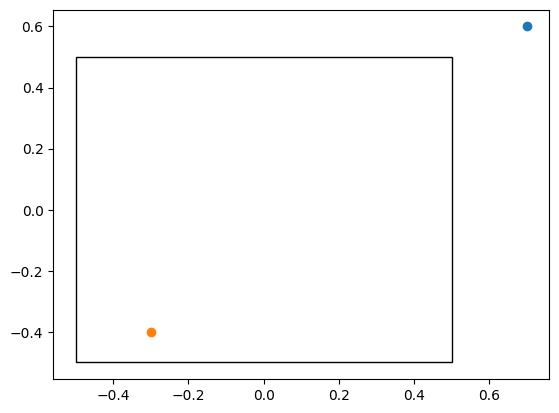

In [17]:
# Demonstrating a 2-D example with L = 1.0
# Here the point's x-coord is inside the box, but the y-coord is outside the unit cell
test_coords = np.array([0.7, 0.6])
pbc_coords = pbc(test_coords, 1.0)

fig, ax = plt.subplots()
box = patches.Rectangle((-0.5, -0.5), width=1.0, height=1.0, edgecolor='k',
                        facecolor='None', linewidth=1.0)
ax.add_patch(box)
ax.scatter(test_coords[0], test_coords[1], label='Original')
ax.scatter(pbc_coords[0], pbc_coords[1], label='PBC')

In [ ]:
def move_point(cur_coords, random_move, box_len : float, box_dist_len=1.0):
    '''Make a move
    '''

    new_coords = cur_coords + (2.0*random_move - 1.0)*box_dist_len

    return pbc(new_coords, box_len)

In [22]:
cur_coords = np.array([0.1, 0.3])
rand_move = np.array([0.3, 0.5])
new_point = move_point(cur_coords, rand_move, 1.0, box_dist_len=0.3)

In [26]:
rng = rand.default_rng()

In [157]:
ensemble_coords = np.zeros((NUM_PARTICLES, 3))

In [151]:
def check_ovlp(cur_coords, prev_coords, dia=1.0):
    num_prev_particles = prev_coords.shape[0]
    for idx in np.arange(num_prev_particles):
        dist = np.linalg.norm(cur_coords - prev_coords[idx, :])
        if dist <= dia:
            # Found particles that overlap
            return True
        
    return False

In [158]:
for idx in np.arange(NUM_PARTICLES):
    coord = rng.uniform(size=3, low=-box_len/2.0, high=box_len/2.0)
    if idx >= 1:
        while (check_ovlp(coord, prev_coords=ensemble_coords[:idx, :], dia=1.0) == True):
            #print(f"idx {idx} overlapped!" )
            coord = rng.uniform(size=3, low=-box_len/2.0, high=box_len/2.0)
    ensemble_coords[idx, :] = coord
    print(f"Generated idx = {idx}! - Coords ({ensemble_coords[idx, 0]}, {ensemble_coords[idx, 1]}, {ensemble_coords[idx, 2]})")

Generated idx = 0! - Coords (0.2472223990109348, -1.7573253645237945, -2.0291701844256207)
Generated idx = 1! - Coords (1.2351090480450466, -0.09155618453994219, -1.1854328469777555)
Generated idx = 2! - Coords (0.6573400464403165, -0.06605474458357641, 1.133000330625768)
Generated idx = 3! - Coords (-0.6822358436004827, 2.379068053731591, 1.3159233772366679)
Generated idx = 4! - Coords (-0.7865557228311844, 2.172485970052713, -1.5333669944523671)
Generated idx = 5! - Coords (1.9534192327256354, -1.8020796423254384, 0.06957769275239611)
Generated idx = 6! - Coords (-2.0420770276229194, -2.4303853868114804, 0.26733312310397483)
Generated idx = 7! - Coords (-1.815141707992948, -0.15997564882500281, 0.48428881506133514)
Generated idx = 8! - Coords (-0.03306158808476578, -0.8614573387511197, 2.3016969361539026)
Generated idx = 9! - Coords (-0.7042752771572092, -0.5735673649098869, -2.1708312292739818)
Generated idx = 10! - Coords (1.64124707512586, -2.2900101366959795, -1.7179597500474086)

In [113]:
# 2D example
init_two_dim = np.zeros((NUM_PARTICLES, 2))
box_len = math.sqrt((NUM_PARTICLES*math.pi*1.0**2)/(4*vol_frac))
for idx in np.arange(NUM_PARTICLES):
    coord = rng.uniform(size=2, low=-box_len/2.0, high=box_len/2.0)
    if idx >= 1:
        while (check_ovlp(coord, prev_coords=init_two_dim[:idx, :], dia=1.0) == True):
            #print(f"idx {idx} overlapped!" )
            coord = rng.uniform(size=2, low=-box_len/2.0, high=box_len/2.0)
    init_two_dim[idx, :] = coord
    print(f"Generated idx = {idx}! - Coords ({init_two_dim[idx, 0]}, {init_two_dim[idx, 1]})")

#fig, ax = plt.subplots()

#ax.scatter(ensemble_coords[:, 0], ensemble_coords[:, 1])
#circle = patches.Circle(ensemble_coords, 1.0, color='r', fill=False, linewidth=2)
#fig.add_p

Generated idx = 0! - Coords (0.5008930712671775, 5.68427867848839)
Generated idx = 1! - Coords (0.418502094029102, -0.034638693263555176)
Generated idx = 2! - Coords (5.883669613496686, 1.6203327392971474)
Generated idx = 3! - Coords (-5.021640838978106, -0.6860899493253942)
Generated idx = 4! - Coords (-3.4296362033661105, 3.028345481921784)
Generated idx = 5! - Coords (1.9451179552286018, -6.565912099681496)
Generated idx = 6! - Coords (1.5385632474191482, -4.562834549061095)
Generated idx = 7! - Coords (-2.163676065432278, 5.610749315371152)
Generated idx = 8! - Coords (-5.021260928010114, 1.2045486312936102)
Generated idx = 9! - Coords (3.76939623792698, 1.4302959165465978)
Generated idx = 10! - Coords (-5.378366977496883, -2.130262365458024)
Generated idx = 11! - Coords (0.6158207143801455, -1.7937727852649994)
Generated idx = 12! - Coords (6.112751214769533, -5.385737664677336)
Generated idx = 13! - Coords (4.8924836069970254, -3.5171925867850953)
Generated idx = 14! - Coords (2.

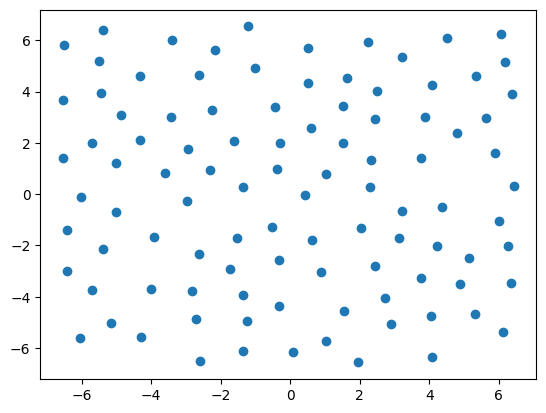

In [116]:
fig, ax = plt.subplots()

ax.scatter(init_two_dim[:, 0], init_two_dim[:, 1])

In [136]:
twod_box_len = math.sqrt((NUM_PARTICLES*math.pi*1.0**2)/(4*vol_frac))

In [147]:
new_ensemble_coords = np.copy(init_two_dim)

accepted_moves = 0
for idx in np.arange(NUM_PARTICLES):
    rand_move = rng.uniform(size=2, high=1.0, low=0.0)

    mask = np.ones(NUM_PARTICLES, dtype=bool)
    mask[idx] = False
    #print(new_ensemble_coords[mask, 0])
    
    cur_coords = new_ensemble_coords[idx, :]
    new_coords = move_point(cur_coords=cur_coords, random_move=rand_move, box_len=twod_box_len,
                            box_dist_len=0.65)
    cond = check_ovlp(new_coords, new_ensemble_coords[mask, :], dia=1.0)

    if cond == True:
        new_ensemble_coords[idx, :] = cur_coords
        #print("Particle Overlapped!")
    else:
        new_ensemble_coords[idx, :] = new_coords
        accepted_moves += 1

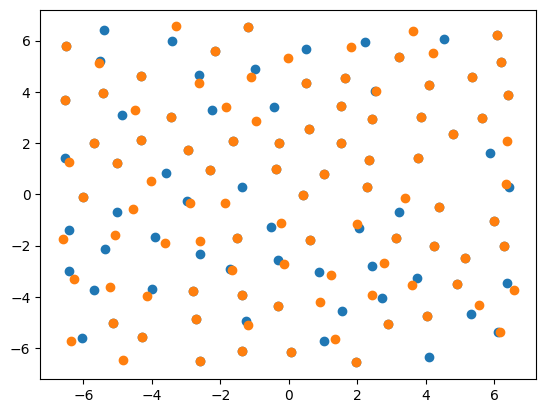

In [148]:
fig, ax = plt.subplots()

ax.scatter(init_two_dim[:, 0], init_two_dim[:, 1])
ax.scatter(new_ensemble_coords[:, 0], new_ensemble_coords[:, 1])

In [149]:
accepted_moves/NUM_PARTICLES

0.43

In [223]:
box_dist_length = np.linspace(0.1, 0.2, 10)
num_trials = 100
acceptance_ratio = np.zeros((100, 10))

In [224]:
for i_idx in np.arange(len(box_dist_length)):
    box_dist_len = box_dist_length[i_idx]
    for trial in np.arange(num_trials):


        new_ensemble_coords = np.copy(ensemble_coords)
        accepted_moves = 0
        for idx in np.arange(NUM_PARTICLES):
            rand_move = rng.uniform(size=3, high=1.0, low=0.0)

            mask = np.ones(NUM_PARTICLES, dtype=bool)
            mask[idx] = False
            
            cur_coords = new_ensemble_coords[idx, :]
            new_coords = move_point(cur_coords=cur_coords, random_move=rand_move, box_len=box_len,
                                    box_dist_len=box_dist_len)
            cond = check_ovlp(new_coords, new_ensemble_coords[mask, :], dia=1.0)

            if cond == True:
                new_ensemble_coords[idx, :] = cur_coords
                #print("Particle Overlapped!")
            else:
                new_ensemble_coords[idx, :] = new_coords
                accepted_moves += 1
        acceptance_ratio[trial, i_idx] += accepted_moves/NUM_PARTICLES


<ErrorbarContainer object of 3 artists>

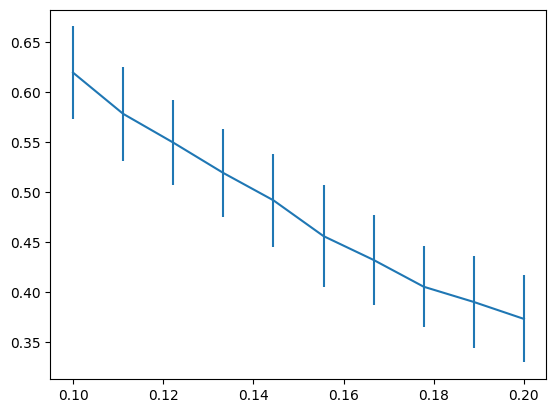

In [225]:
fig, ax = plt.subplots()
ax.errorbar(box_dist_length, np.average(acceptance_ratio, axis=0), yerr=np.std(acceptance_ratio, axis=0))